# HW8 Country Profile Matplotlib Answer Key

Answer key notebook. Run cells from top to bottom.

The notebook uses the included `country_profile_variables.csv` dataset and follows the reference notebook style.

In [1]:
from google.colab import files
f = files.upload()

Saving M8_country_profile_variables.csv to M8_country_profile_variables.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

country = pd.read_csv("M8_country_profile_variables.csv")
country.head()

,Unnamed: 0,Country,Surface area (km2),"Population 1,000 (2017)",GDP (M US$),Life Exp Female,Life Exp Male
0,1,Afghanistan,652864,35530,20270,63.5,61.0
1,2,Albania,28748,2930,11541,79.9,75.6
2,3,Algeria,2381741,41318,164779,76.5,74.1
3,4,American Samoa,199,56,-99,77.8,71.1
4,5,Angola,1246700,29784,117955,63.0,57.4


## Problem 1.1

In [5]:
country["Difference"] = country["Life Exp Female"] - country["Life Exp Male"]

top10_difference = country.sort_values("Difference", ascending=False).head(10)
display(top10_difference[["Country", "Life Exp Female", "Life Exp Male", "Difference"]])

usa_difference = country.loc[
    country["Country"].eq("United States of America"),
    ["Country", "Life Exp Female", "Life Exp Male", "Difference"]
]
usa_difference

,Country,Life Exp Female,Life Exp Male,Difference
182,Syrian Arab Republic,76.3,64.4,11.9
154,Russian Federation,75.9,64.7,11.2
16,Belarus,77.7,66.5,11.2
107,Lithuania,79.3,68.5,10.8
102,Latvia,78.7,68.8,9.9
195,Ukraine,76.0,66.1,9.9
141,Palau,77.8,68.1,9.7
96,Kazakhstan,73.9,64.3,9.6
205,Viet Nam,80.3,70.7,9.6
60,Estonia,81.2,71.8,9.4


,Country,Life Exp Female,Life Exp Male,Difference
199,United States of America,81.2,76.5,4.7


## Problem 1.2

In [6]:
country["Average Life Expectancy"] = (
    country["Life Exp Female"] + country["Life Exp Male"]
) / 2

country[["Country", "Life Exp Female", "Life Exp Male", "Average Life Expectancy"]].head()

,Country,Life Exp Female,Life Exp Male,Average Life Expectancy
0,Afghanistan,63.5,61.0,62.25
1,Albania,79.9,75.6,77.75
2,Algeria,76.5,74.1,75.30
3,American Samoa,77.8,71.1,74.45
4,Angola,63.0,57.4,60.20


## Problem 1.3: GDP vs Average Life Expectancy

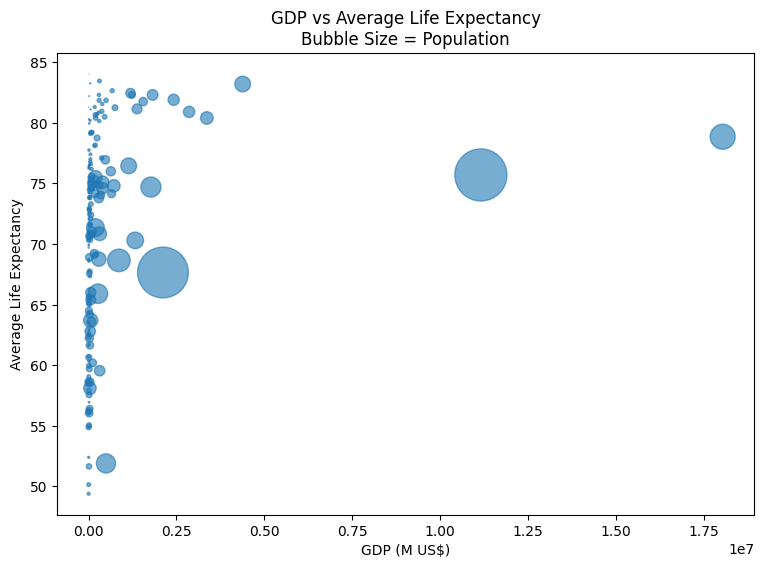

In [8]:
valid_gdp = country[country["GDP (M US$)"] > 0].copy()

plt.figure(figsize=(9, 6))
plt.scatter(
    valid_gdp["GDP (M US$)"],
    valid_gdp["Average Life Expectancy"],
    s=valid_gdp["Population 1,000  (2017)"] / 1000, # Corrected column name
    alpha=0.6
)
plt.xlabel("GDP (M US$)")
plt.ylabel("Average Life Expectancy")
plt.title("GDP vs Average Life Expectancy\nBubble Size = Population")
plt.show()

/usr/local/lib/python3.12/dist-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


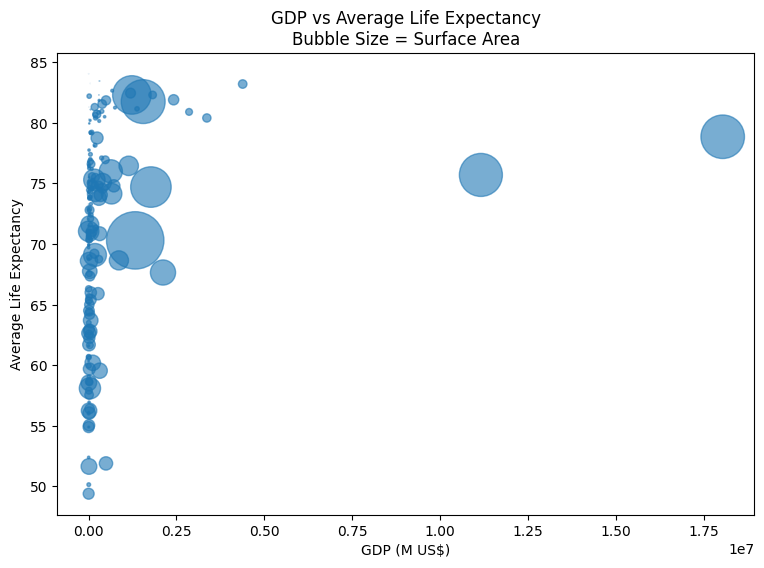

In [9]:
plt.figure(figsize=(9, 6))
plt.scatter(
    valid_gdp["GDP (M US$)"],
    valid_gdp["Average Life Expectancy"],
    s=valid_gdp["Surface area (km2)"] / 10000,
    alpha=0.6
)
plt.xlabel("GDP (M US$)")
plt.ylabel("Average Life Expectancy")
plt.title("GDP vs Average Life Expectancy\nBubble Size = Surface Area")
plt.show()

## Problem 1.4: Natural Log GDP vs Average Life Expectancy

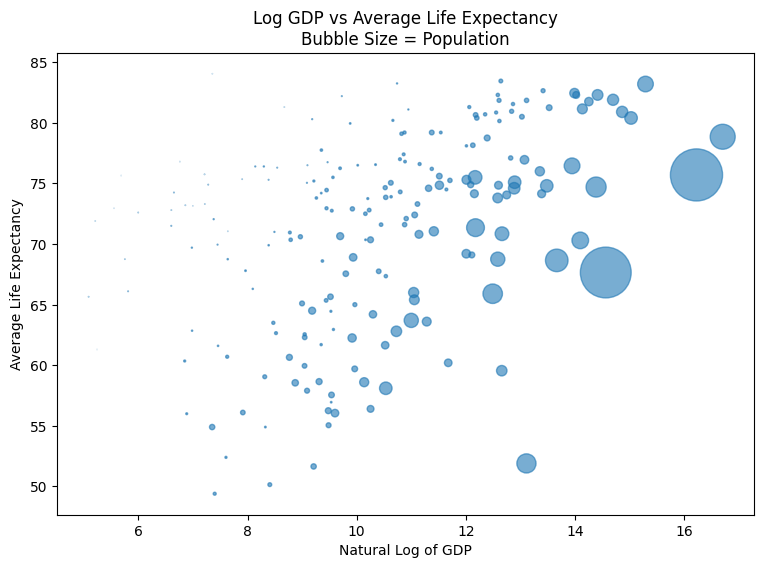

In [11]:
valid_gdp["Log GDP"] = np.log(valid_gdp["GDP (M US$)"])

plt.figure(figsize=(9, 6))
plt.scatter(
    valid_gdp["Log GDP"],
    valid_gdp["Average Life Expectancy"],
    s=valid_gdp["Population 1,000  (2017)"] / 1000, # Corrected column name
    alpha=0.6
)
plt.xlabel("Natural Log of GDP")
plt.ylabel("Average Life Expectancy")
plt.title("Log GDP vs Average Life Expectancy\nBubble Size = Population")
plt.show()

/usr/local/lib/python3.12/dist-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


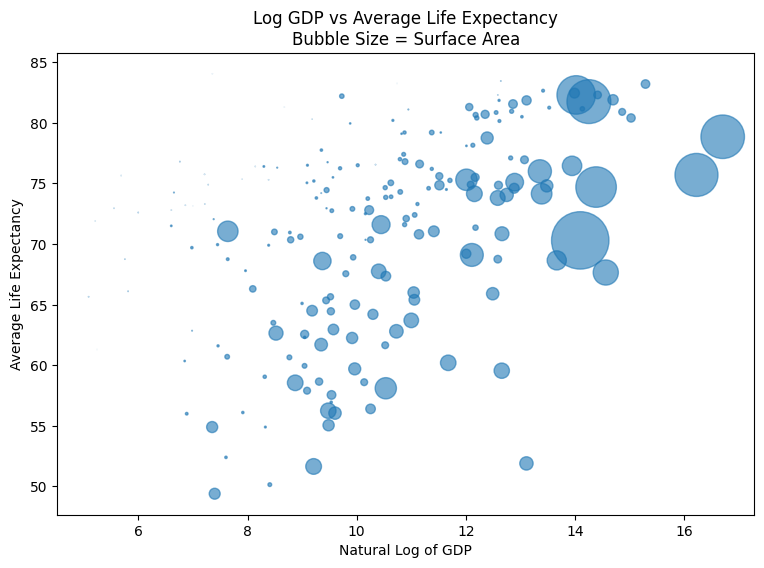

In [12]:
plt.figure(figsize=(9, 6))
plt.scatter(
    valid_gdp["Log GDP"],
    valid_gdp["Average Life Expectancy"],
    s=valid_gdp["Surface area (km2)"] / 10000,
    alpha=0.6
)
plt.xlabel("Natural Log of GDP")
plt.ylabel("Average Life Expectancy")
plt.title("Log GDP vs Average Life Expectancy\nBubble Size = Surface Area")
plt.show()